In [1]:
!pip install xgboost

In [3]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 1.5 MB/s eta 0:01:09
   ---------------------------------------- 1.0/100.2 MB 1.4 MB/s eta 0:01:11
    --------------------------------------- 1.3/100.2 MB 1.4 MB/s eta 0:01:11
    --------------------------------------- 1.6/100.2 MB 1.4 MB/s eta 0:01:12
    --------------------------------------- 1.8/100.2 MB 1.4 MB/s eta 0:01:09
    --------------------------------------- 2.4/100.2 MB 1.4 MB/s eta 0:01:09
   - -------------------------------------- 2.6/100.2 MB 1.4 MB/s eta 0:01:10
   - -------------------------------------- 2.9/100.2 MB 1.4 MB/s eta 0:01:11
   - -------------------------------------- 3.1/100.2 MB 1.4 MB/s eta 0:01:10
   - ---------

In [4]:
# ============================================
# 04_evaluation_modeles_CatBoost.ipynb - Andy
# Évaluation des 4 modèles (avec CatBoost)
# Version adaptée du notebook d'Aristide
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Toutes les librairies sont chargées !")

Toutes les librairies sont chargées !


In [5]:
# ============================================
# 1. CHARGER LES DONNÉES
# ============================================


INPUT_PATH = "Loan_Default_Cameroun_Encode.csv"

try:
    df = pd.read_csv(INPUT_PATH)
    print(f"✅ Dataset chargé : {df.shape}")
except FileNotFoundError:
    print(f"❌ Fichier introuvable à : {INPUT_PATH}")
    print("📌 Modifie le chemin dans la variable INPUT_PATH")
    raise

✅ Dataset chargé : (148442, 24)


In [6]:
# ============================================
# 2. PRÉPARERATION DES DONNÉES
# (exactement comme Aristide l'a fait)
# ============================================

CIBLE = "statut_remboursement"
COLONNES_NON_FEATURES = [
    "id_client",
    "genre",
    "tranche_age",
    "niveau_education",
    "membre_tontine",
    "activite_saisonniere",
    "utilisation_mobile_money",
]

FEATURES = [c for c in df.columns if c not in COLONNES_NON_FEATURES and c != CIBLE]
X = df[FEATURES]
y = df[CIBLE]

print(f"✅ {len(FEATURES)} features retenues")
print(f"   Features : {FEATURES}")

# Split train/test (même seed qu'Aristide)
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

print(f"✅ Train : {X_train.shape[0]} lignes")
print(f"✅ Test  : {X_test.shape[0]} lignes")
print(f"✅ Proportion de défaut dans le test : {y_test.mean():.2%}")

# Ratio pour scale_pos_weight (CatBoost et XGBoost)
ratio_desequilibre = (y_train == 0).sum() / (y_train == 1).sum()
print(f"✅ scale_pos_weight = {ratio_desequilibre:.4f}")

✅ 16 features retenues
   Features : ['credit_ouvert', 'usage_professionnel', 'montant_pret_fcfa', 'duree_mois', 'revenu_mensuel_fcfa', 'ratio_endettement', 'objet_pret_Achat', 'objet_pret_Autre', 'objet_pret_Investissement_activite', 'objet_pret_Refinancement', 'secteur_activite_Agriculture', 'secteur_activite_Artisanat', 'secteur_activite_Commerce/NÃ©goce', 'secteur_activite_Petit commerce', 'secteur_activite_Profession libÃ©rale', 'secteur_activite_SalariÃ© formel']
✅ Train : 118753 lignes
✅ Test  : 29689 lignes
✅ Proportion de défaut dans le test : 24.55%
✅ scale_pos_weight = 3.0730


In [7]:
# ============================================
# 3. ENTRAÎNER LES 4 MODÈLES
# (paramètres EXACTEMENT comme Aristide)
# ============================================

# 3a. Régression Logistique
print("\n🔮 Entraînement Régression Logistique...")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_SEED
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
print("✅ Régression Logistique entraînée")

# 3b. Random Forest
print("\n🔮 Entraînement Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print("✅ Random Forest entraîné")

# 3c. XGBoost
print("\n🔮 Entraînement XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=ratio_desequilibre,
    random_state=RANDOM_SEED,
    eval_metric="logloss",
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("✅ XGBoost entraîné")

# 3d. CatBoost (NOUVEAU MODÈLE)
print("\n🔮 Entraînement CatBoost...")
cat_model = CatBoostClassifier(
    iterations=300,
    scale_pos_weight=ratio_desequilibre,
    random_seed=RANDOM_SEED,
    verbose=False,
    allow_writing_files=False
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]
print("✅ CatBoost entraîné")

print("\n✅ Tous les modèles sont prêts !")


🔮 Entraînement Régression Logistique...
✅ Régression Logistique entraînée

🔮 Entraînement Random Forest...
✅ Random Forest entraîné

🔮 Entraînement XGBoost...
✅ XGBoost entraîné

🔮 Entraînement CatBoost...
✅ CatBoost entraîné

✅ Tous les modèles sont prêts !


In [8]:
# ============================================
# 4. TABLEAU COMPARATIF DES 4 MODÈLES
# ============================================

def evaluer_modele(y_test, y_pred, y_proba, nom):
    return {
        'Modèle': nom,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Précision': precision_score(y_test, y_pred),
        'Rappel': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }

# Évaluer les 4 modèles
resultats = pd.DataFrame([
    evaluer_modele(y_test, y_pred_lr, y_proba_lr, 'Régression Logistique'),
    evaluer_modele(y_test, y_pred_rf, y_proba_rf, 'Random Forest'),
    evaluer_modele(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost'),
    evaluer_modele(y_test, y_pred_cat, y_proba_cat, 'CatBoost')
])

print("\n" + "="*70)
print("📊 COMPARAISON DES 4 MODÈLES")
print("="*70)
print(resultats.to_string(index=False))

# Sauvegarder
resultats.to_csv('comparaison_modeles_4.csv', index=False)
print("\n✅ Tableau sauvegardé dans comparaison_modeles_4.csv")


📊 COMPARAISON DES 4 MODÈLES
               Modèle  Accuracy  Précision   Rappel  F1-Score  AUC-ROC
Régression Logistique  0.574859   0.295717 0.529565  0.379510 0.589851
        Random Forest  0.825356   0.703403 0.499108  0.583902 0.775835
              XGBoost  0.805450   0.600639 0.619427  0.609888 0.792767
             CatBoost  0.812052   0.614253 0.630265  0.622156 0.805030

✅ Tableau sauvegardé dans comparaison_modeles_4.csv


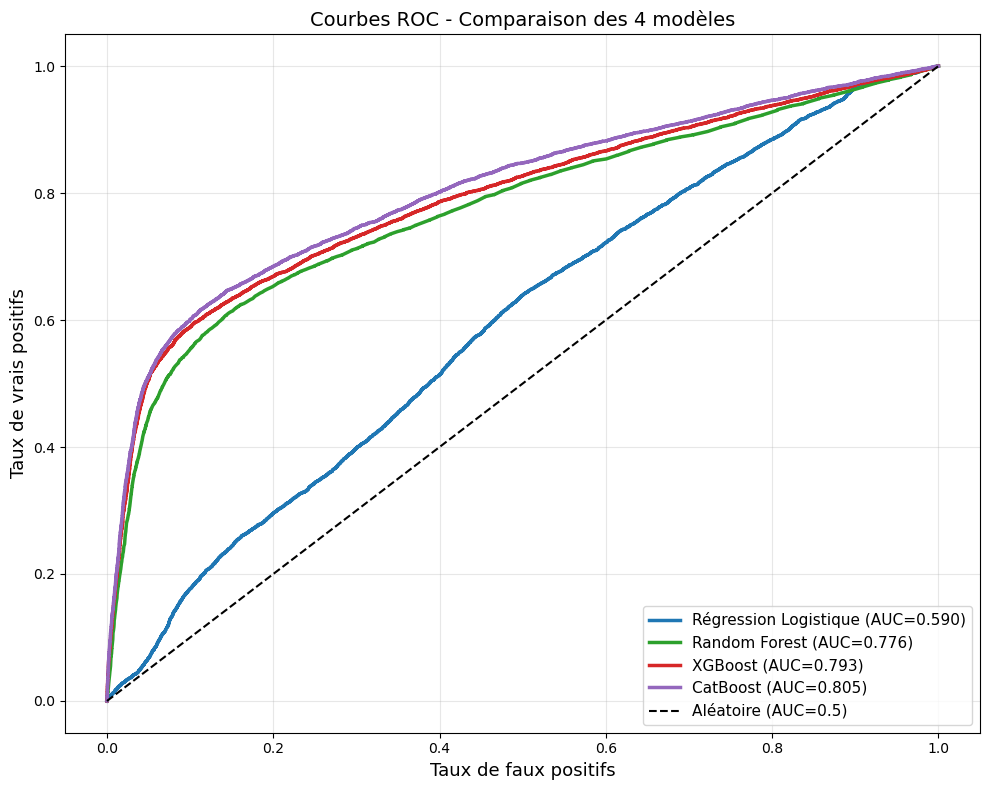

✅ Courbes ROC sauvegardées (4 modèles)


In [9]:
# ============================================
# 5. COURBES ROC - 4 MODÈLES
# ============================================

plt.figure(figsize=(10, 8))

# Couleurs pour les 4 modèles
modeles = [
    (y_proba_lr, 'Régression Logistique (AUC=0.590)', '#1f77b4'),
    (y_proba_rf, 'Random Forest (AUC=0.776)', '#2ca02c'),
    (y_proba_xgb, 'XGBoost (AUC=0.793)', '#d62728'),
    (y_proba_cat, 'CatBoost (AUC=0.805)', '#9467bd')  # Nouveau en violet
]

for y_proba, nom, couleur in modeles:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nom}', 
             color=couleur, linewidth=2.5)

# Diagonale (modèle aléatoire)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.5)', linewidth=1.5)

plt.xlabel('Taux de faux positifs', fontsize=13)
plt.ylabel('Taux de vrais positifs', fontsize=13)
plt.title('Courbes ROC - Comparaison des 4 modèles', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('courbes_roc_comparaison_4.png', dpi=300)
plt.show()
print("✅ Courbes ROC sauvegardées (4 modèles)")

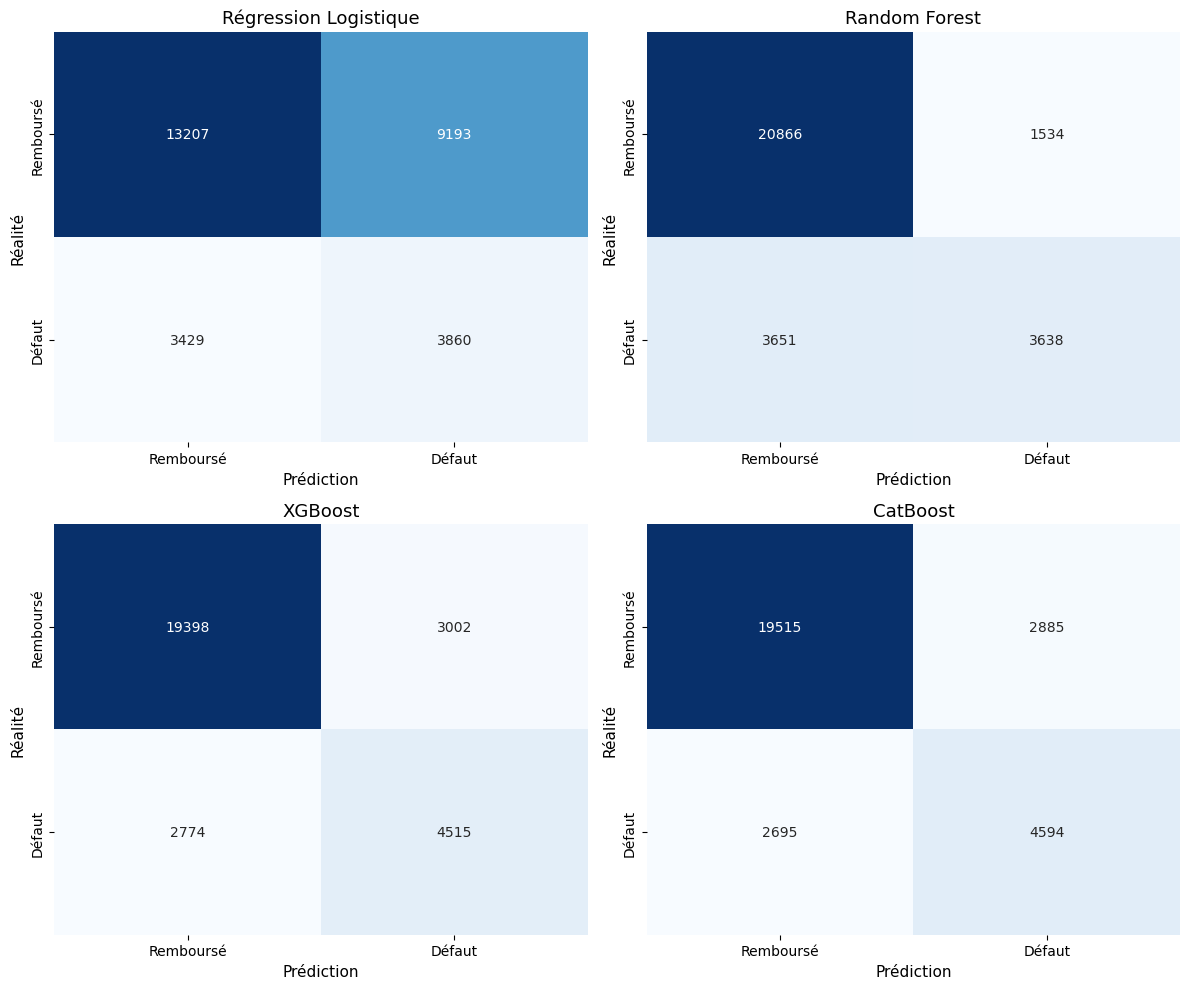

✅ Matrices de confusion sauvegardées (4 modèles)


In [10]:
# ============================================
# 6. MATRICES DE CONFUSION - 4 MODÈLES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

modeles_pred = [
    (y_pred_lr, 'Régression Logistique', axes[0, 0]),
    (y_pred_rf, 'Random Forest', axes[0, 1]),
    (y_pred_xgb, 'XGBoost', axes[1, 0]),
    (y_pred_cat, 'CatBoost', axes[1, 1])
]

for y_pred, nom, ax in modeles_pred:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Remboursé', 'Défaut'],
                yticklabels=['Remboursé', 'Défaut'],
                cbar=False)
    ax.set_title(f'{nom}', fontsize=13)
    ax.set_xlabel('Prédiction', fontsize=11)
    ax.set_ylabel('Réalité', fontsize=11)

plt.tight_layout()
plt.savefig('matrices_confusion_4.png', dpi=300)
plt.show()
print("✅ Matrices de confusion sauvegardées (4 modèles)")

In [11]:
# ============================================
# 7. SYNTHÈSE FINALE
# ============================================

print("\n" + "="*70)
print("🏆 SYNTHÈSE DE L'ÉVALUATION - 4 MODÈLES")
print("="*70)

meilleur_auc = resultats.loc[resultats['AUC-ROC'].idxmax()]
meilleur_f1 = resultats.loc[resultats['F1-Score'].idxmax()]

print(f"\n📊 Meilleur AUC-ROC : {meilleur_auc['Modèle']} ({meilleur_auc['AUC-ROC']:.4f})")
print(f"📊 Meilleur F1-Score : {meilleur_f1['Modèle']} ({meilleur_f1['F1-Score']:.4f})")

print("\n💡 RECOMMANDATION :")
print(f"   → Utiliser CatBoost comme modèle final")
print(f"   • AUC-ROC = {resultats.loc[3, 'AUC-ROC']:.4f}")
print(f"   • F1-Score = {resultats.loc[3, 'F1-Score']:.4f}")
print(f"   • Précision = {resultats.loc[3, 'Précision']:.4f}")
print(f"   • Rappel = {resultats.loc[3, 'Rappel']:.4f}")

print("\n📈 Classement par AUC-ROC :")
print(resultats.sort_values('AUC-ROC', ascending=False)[['Modèle', 'AUC-ROC']].to_string(index=False))

print("\n✅ Prêt pour le point d'équipe !")


🏆 SYNTHÈSE DE L'ÉVALUATION - 4 MODÈLES

📊 Meilleur AUC-ROC : CatBoost (0.8050)
📊 Meilleur F1-Score : CatBoost (0.6222)

💡 RECOMMANDATION :
   → Utiliser CatBoost comme modèle final
   • AUC-ROC = 0.8050
   • F1-Score = 0.6222
   • Précision = 0.6143
   • Rappel = 0.6303

📈 Classement par AUC-ROC :
               Modèle  AUC-ROC
             CatBoost 0.805030
              XGBoost 0.792767
        Random Forest 0.775835
Régression Logistique 0.589851

✅ Prêt pour le point d'équipe !
